# Notebook 02 — Exploratory Data Analysis (4 Subset)

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option("display.max_columns", None)

PROCESSED_DIR = '../processed'
SUBSETS       = ['FD001', 'FD002', 'FD003', 'FD004']
SUBSET_INFO   = {
    'FD001': {'op_cond': 1, 'fault_modes': 1, 'n_train_engines': 100, 'n_test_engines': 100},
    'FD002': {'op_cond': 6, 'fault_modes': 1, 'n_train_engines': 260, 'n_test_engines': 259},
    'FD003': {'op_cond': 1, 'fault_modes': 2, 'n_train_engines': 100, 'n_test_engines': 100},
    'FD004': {'op_cond': 6, 'fault_modes': 2, 'n_train_engines': 249, 'n_test_engines': 248},
}
print("EDA siap. Subset target :", SUBSETS)

EDA siap. Subset target : ['FD001', 'FD002', 'FD003', 'FD004']


## 1. Ringkasan Karakteristik Tiap Subset

In [2]:
# Tabel kompleksitas seluruh subset (acuan literatur Saxena 2008, Heimes 2008)
df_summary = pd.DataFrame.from_dict(SUBSET_INFO, orient='index').reset_index()
df_summary = df_summary.rename(columns={'index': 'subset'})
df_summary['complexity'] = df_summary.apply(
    lambda r: f"{r['op_cond']} OC × {r['fault_modes']} FM", axis=1)
df_summary

,subset,op_cond,fault_modes,n_train_engines,n_test_engines,complexity
0,FD001,1,1,100,100,1 OC × 1 FM
1,FD002,6,1,260,259,6 OC × 1 FM
2,FD003,1,2,100,100,1 OC × 2 FM
3,FD004,6,2,249,248,6 OC × 2 FM


## 2. Distribusi Engine Lifespan per Subset (Side-by-Side)

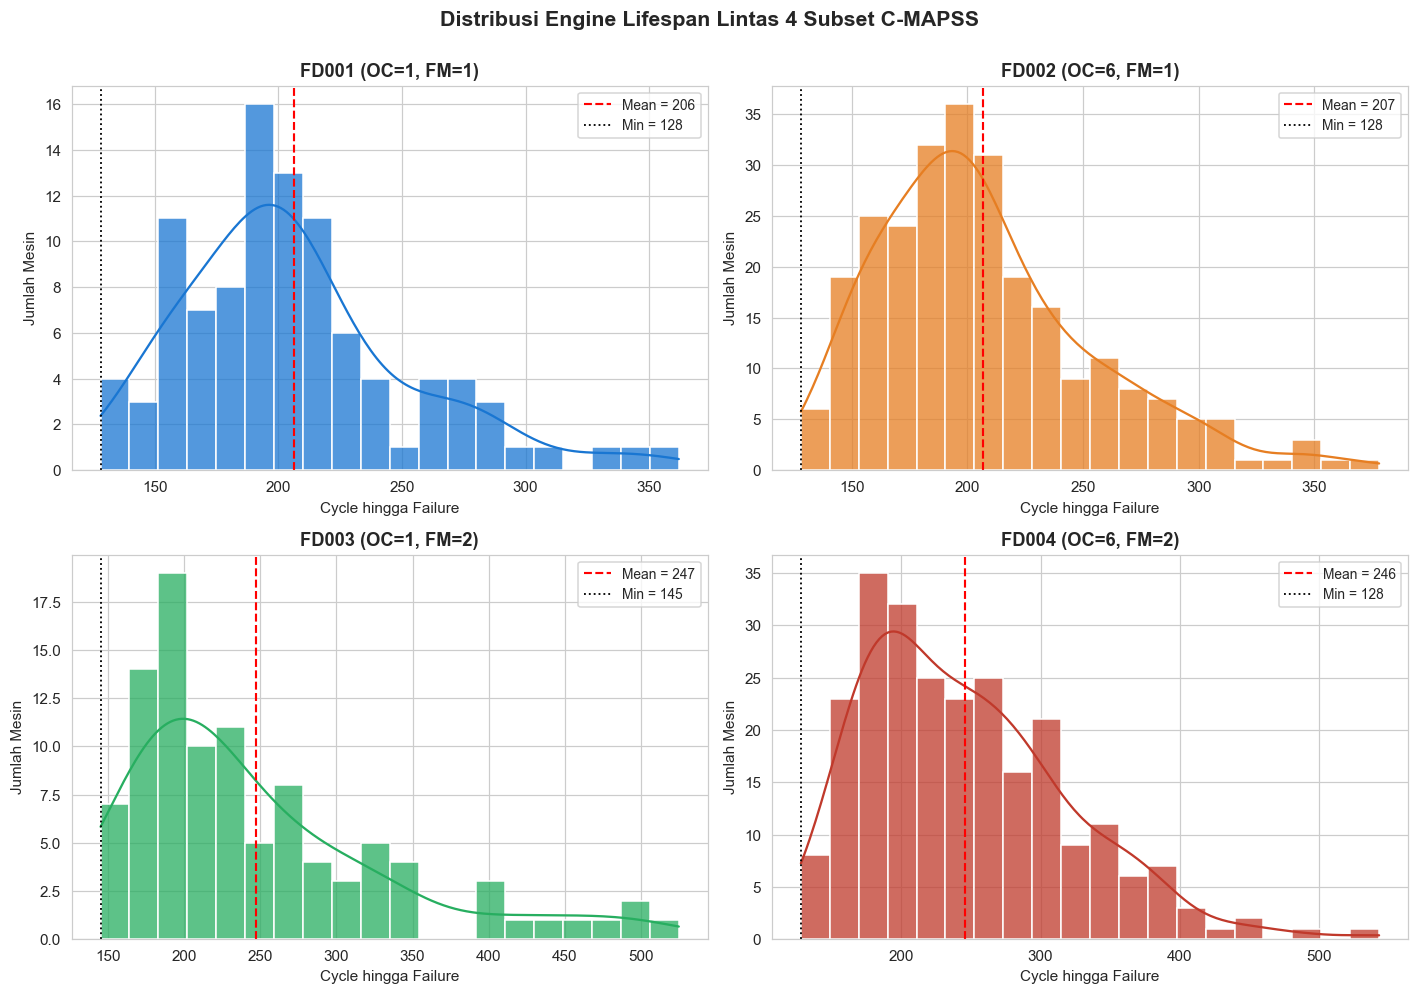

,mean,std,min,max
FD001,206.31,46.34,128.0,362.0
FD002,206.77,46.78,128.0,378.0
FD003,247.20,86.48,145.0,525.0
FD004,245.98,73.11,128.0,543.0


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
colors = ['#1976D2', '#E67E22', '#27AE60', '#C0392B']

lifespan_stats = {}
for i, s in enumerate(SUBSETS):
    df = pd.read_csv(f'{PROCESSED_DIR}/{s}/train_2d.csv')
    lifespan = df.groupby('unit_number')['time_cycles'].max()
    lifespan_stats[s] = {
        'mean': lifespan.mean(),
        'std' : lifespan.std(),
        'min' : lifespan.min(),
        'max' : lifespan.max(),
    }
    sns.histplot(lifespan, kde=True, color=colors[i], bins=20, ax=axes[i], alpha=0.75)
    axes[i].axvline(lifespan.mean(), color='red',  linestyle='--', linewidth=1.4,
                    label=f'Mean = {lifespan.mean():.0f}')
    axes[i].axvline(lifespan.min(),  color='black',linestyle=':',  linewidth=1.2,
                    label=f'Min = {lifespan.min():.0f}')
    axes[i].set_title(f'{s} (OC={SUBSET_INFO[s]["op_cond"]}, FM={SUBSET_INFO[s]["fault_modes"]})',
                      fontweight='bold')
    axes[i].set_xlabel('Cycle hingga Failure'); axes[i].set_ylabel('Jumlah Mesin')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribusi Engine Lifespan Lintas 4 Subset C-MAPSS',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../output/eda_lifespan_4subsets.png', dpi=300, bbox_inches='tight')
plt.show()

pd.DataFrame(lifespan_stats).T.round(2)

## 3. Korelasi Sensor terhadap RUL (Heatmap Side-by-Side)

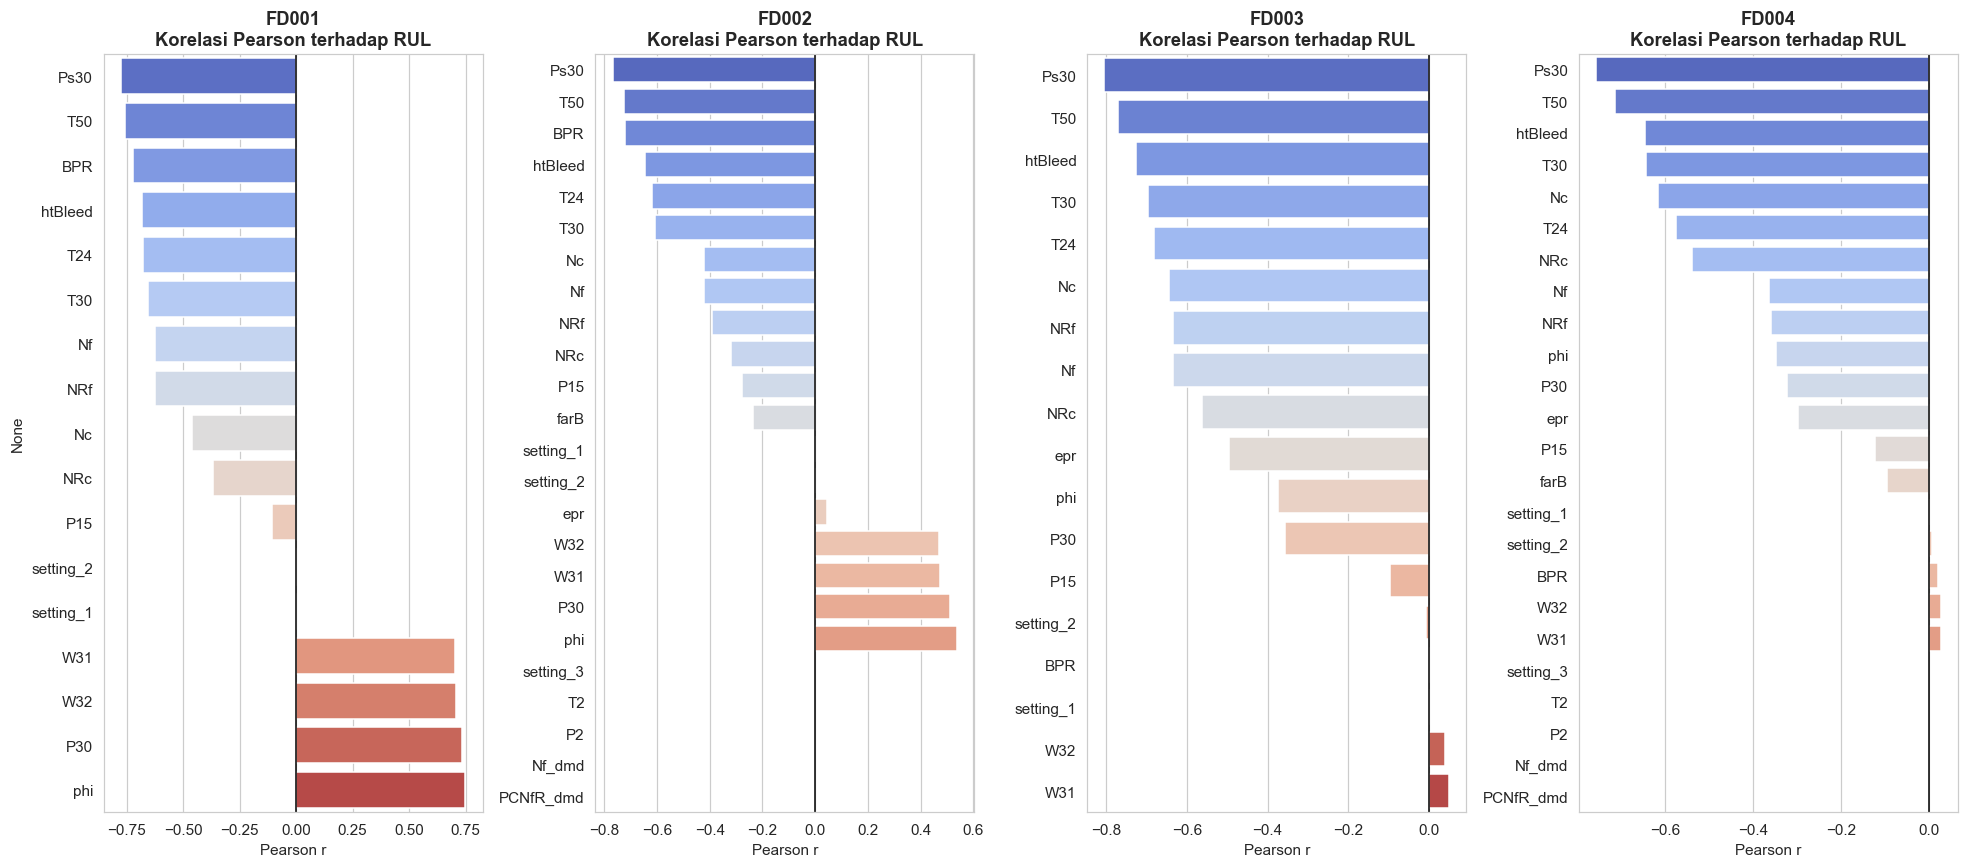

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 8))
for i, s in enumerate(SUBSETS):
    df = pd.read_csv(f'{PROCESSED_DIR}/{s}/train_2d.csv')
    feature_cols = [c for c in df.columns if c not in ['unit_number','time_cycles','RUL']]
    corr = df[feature_cols + ['RUL']].corr()['RUL'].drop('RUL').sort_values()
    sns.barplot(x=corr.values, y=corr.index, palette='coolwarm', ax=axes[i])
    axes[i].axvline(0, color='black', linewidth=1)
    axes[i].set_title(f'{s}\nKorelasi Pearson terhadap RUL', fontweight='bold')
    axes[i].set_xlabel('Pearson r')
    if i > 0:
        axes[i].set_ylabel('')
plt.tight_layout()
plt.savefig('../output/eda_correlation_4subsets.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Visualisasi Trajektori Sensor (Engine Sample)

Mengambil 4 mesin acak dari masing-masing subset, lalu menampilkan trajektori sensor T24 (LPC outlet temperature) — sensor yang umumnya berkorelasi kuat
dengan degradasi turbofan.

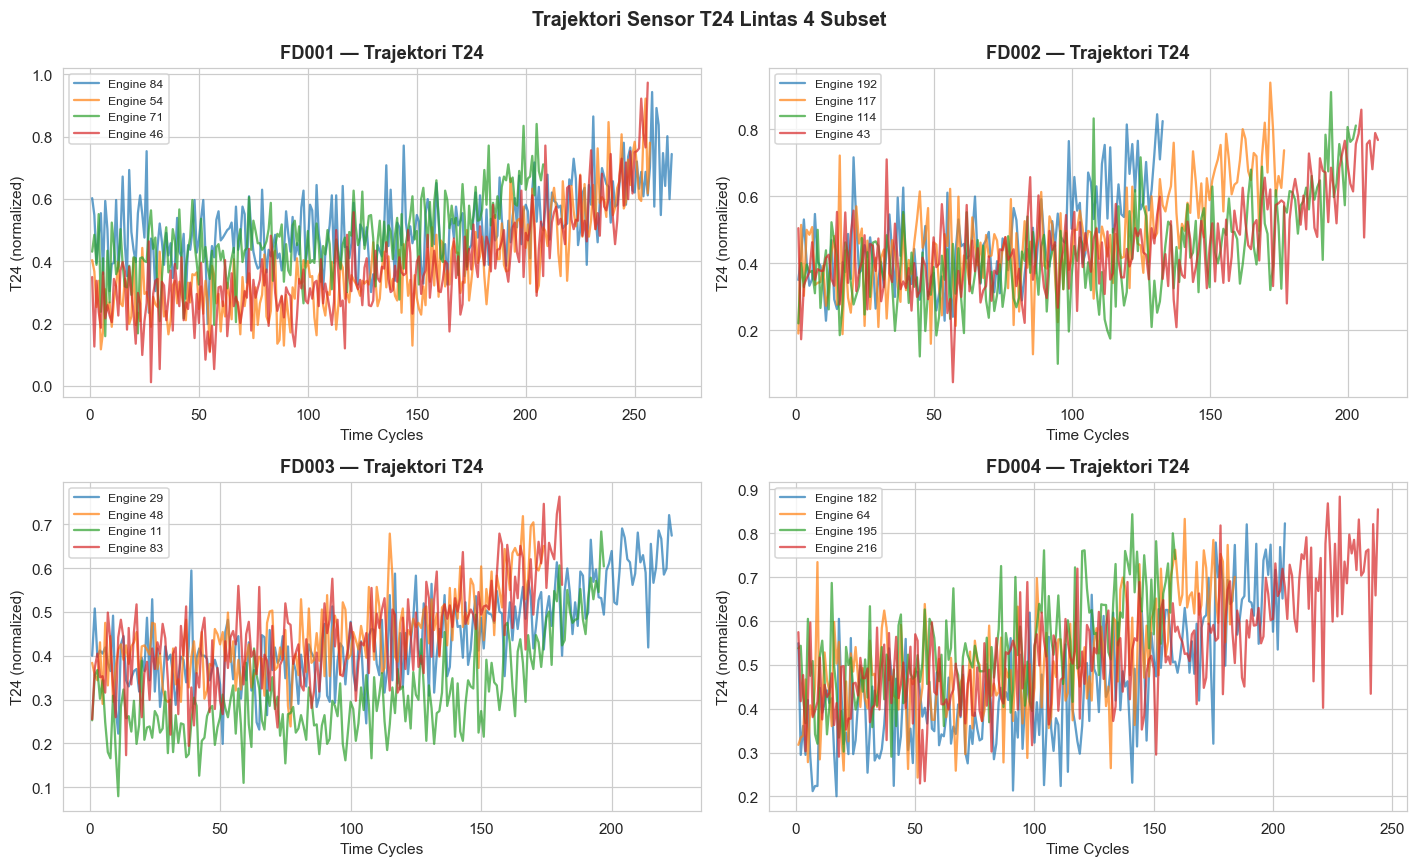

In [5]:
SAMPLE_SENSOR = 'T24'
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
np.random.seed(42)

for i, s in enumerate(SUBSETS):
    df = pd.read_csv(f'{PROCESSED_DIR}/{s}/train_2d.csv')
    if SAMPLE_SENSOR not in df.columns:
        axes[i].text(0.5, 0.5, f'{SAMPLE_SENSOR} tidak ada di {s}',
                     ha='center', va='center', transform=axes[i].transAxes)
        continue
    units = np.random.choice(df['unit_number'].unique(),
                             size=min(4, df['unit_number'].nunique()), replace=False)
    for u in units:
        sub = df[df['unit_number'] == u]
        axes[i].plot(sub['time_cycles'], sub[SAMPLE_SENSOR], alpha=0.7, label=f'Engine {u}')
    axes[i].set_title(f'{s} — Trajektori {SAMPLE_SENSOR}', fontweight='bold')
    axes[i].set_xlabel('Time Cycles'); axes[i].set_ylabel(f'{SAMPLE_SENSOR} (normalized)')
    axes[i].legend(fontsize=8)

plt.suptitle(f'Trajektori Sensor {SAMPLE_SENSOR} Lintas 4 Subset', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../output/eda_trajectory_4subsets.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Scatter Operating Settings (FD002/FD004 — Multi-Condition)

Memvisualisasikan kompleksitas operating-condition pada FD002 dan FD004 yang
membenarkan pendekatan **condition-aware normalization** pada Notebook 01.

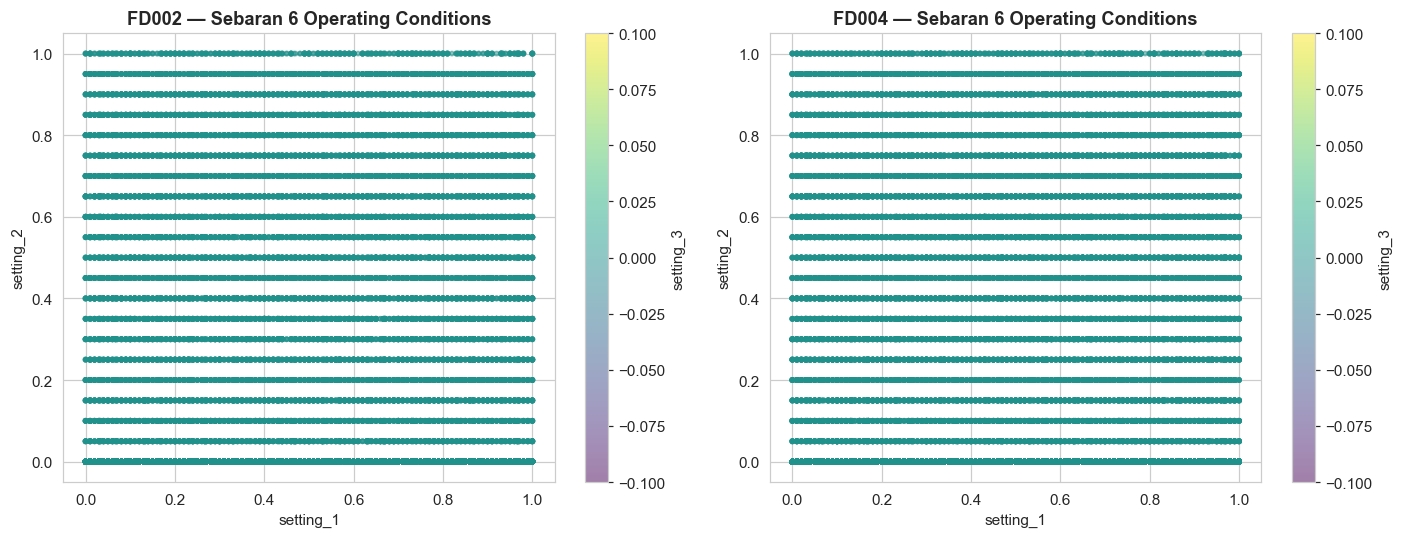

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, s in enumerate(['FD002', 'FD004']):
    df = pd.read_csv(f'{PROCESSED_DIR}/{s}/train_2d.csv')
    if all(c in df.columns for c in ['setting_1','setting_2','setting_3']):
        sc = axes[i].scatter(df['setting_1'], df['setting_2'],
                             c=df['setting_3'], cmap='viridis', alpha=0.5, s=8)
        plt.colorbar(sc, ax=axes[i], label='setting_3')
        axes[i].set_title(f'{s} — Sebaran 6 Operating Conditions', fontweight='bold')
        axes[i].set_xlabel('setting_1'); axes[i].set_ylabel('setting_2')
plt.tight_layout()
plt.savefig('../output/eda_op_conditions.png', dpi=300, bbox_inches='tight')
plt.show()